In [74]:
## Had to use duckdb to utilize SQL, still waiting for installation of PostgreSQL on my laptop

In [75]:
!pip install jupysql duckdb-engine pandas

In [76]:
## Loading in duckdb extension

In [77]:
%load_ext sql
%sql duckdb://

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [78]:
## Loading in matplotlib and plot packages

In [79]:
import plotly.express as px
import matplotlib.pyplot as plt

In [80]:
## Clear any failed transactions out of memory and reset the database connection state

In [81]:
%%sql
ROLLBACK;

Running query in 'duckdb://'

Success


In [82]:
## Installing spatial extension package and unlocking ability to parse Excel data

In [83]:
%%sql
INSTALL spatial;
LOAD spatial;

Running query in 'duckdb://'

Success


In [84]:
## Clear any failed transactions out of memory and reset the database connection state

In [85]:
%%sql
ROLLBACK;

Running query in 'duckdb://'

Success


In [86]:
## Reading in dataset under alias retail_data

In [87]:
%%sql
CREATE OR REPLACE VIEW retail_data AS 
SELECT * FROM st_read('Data/Retail_Supply_Chain_Sales_Dataset.xlsx', layer = 'Retails Order Full Dataset');

Running query in 'duckdb://'

Count


In [88]:
%%sql
SELECT * FROM retail_data LIMIT 5;

Running query in 'duckdb://'

OGC_FID,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Retail Sales People,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit
2,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Cassandra Brandow,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,Not,261.96,2,0.0,41.9136
3,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Cassandra Brandow,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",Not,731.94,3,0.0,219.582
4,3,CA-2016-138688,2016-12-06,2016-12-06,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,Anna Andreadi,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,Not,14.62,2,0.0,6.8714
5,4,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Cassandra Brandow,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,Not,957.5775,5,0.45,-383.031
6,5,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Cassandra Brandow,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,Not,22.368,2,0.2,2.5164


In [89]:
%%sql
Select COUNT(*)
From retail_data;

Running query in 'duckdb://'

count_star()
9994


In [90]:
%%sql
Select COUNT(DISTINCT "Order ID"),COUNT(DISTINCT "Customer ID"),COUNT(DISTINCT "Product ID")
From retail_data;

Running query in 'duckdb://'

"count(DISTINCT ""Order ID"")","count(DISTINCT ""Customer ID"")","count(DISTINCT ""Product ID"")"
5009,793,1862


In [91]:
# CUSTOMER ANALYSIS

In [92]:
## Most Profitable Customers

In [93]:
%%sql
Select "Customer ID", "Customer Name", 
        ROUND(SUM(sales),2) AS Total_Sales,
        ROUND(SUM(profit),2) AS Total_Profit,
        ROUND(SUM(profit) / NULLIF(SUM(sales),0) * 100, 2) As Profit_Margin,
        COUNT("Order ID") AS Total_Orders
From retail_data
GROUP BY "Customer ID", "Customer Name"
ORDER BY Total_Profit DESC;

Running query in 'duckdb://'

Customer ID,Customer Name,Total_Sales,Total_Profit,Profit_Margin,Total_Orders
TC-20980,Tamara Chand,19052.22,8981.32,47.14,12
RB-19360,Raymond Buch,15117.34,6976.1,46.15,18
SC-20095,Sanjit Chand,14142.33,5757.41,40.71,22
HL-15040,Hunter Lopez,12873.3,5622.43,43.68,11
AB-10105,Adrian Barton,14473.57,5444.81,37.62,20
TA-21385,Tom Ashbrook,14595.62,4703.79,32.23,10
CM-12385,Christopher Martinez,8954.02,3899.89,43.55,10
KD-16495,Keith Dawkins,8181.26,3038.63,37.14,28
AR-10540,Andy Reiter,6608.45,2884.62,43.65,9
DR-12940,Daniel Raglin,8350.87,2869.08,34.36,13


In [94]:
## Highest-margin customers

In [95]:
%%sql
Select "Customer ID", "Customer Name", 
        ROUND(SUM(sales),2) AS Total_Sales,
        ROUND(SUM(profit),2) AS Total_Profit,
        ROUND(SUM(profit) / NULLIF(SUM(sales),0) * 100, 2) As Profit_Margin,
        COUNT("Order ID") AS Total_Orders
From retail_data
GROUP BY "Customer ID", "Customer Name"
ORDER BY Profit_Margin DESC;

Running query in 'duckdb://'

Customer ID,Customer Name,Total_Sales,Total_Profit,Profit_Margin,Total_Orders
JC-15385,Jenna Caffey,1058.11,502.92,47.53,4
TC-20980,Tamara Chand,19052.22,8981.32,47.14,12
RB-19360,Raymond Buch,15117.34,6976.1,46.15,18
SR-20740,Steven Roelle,4345.89,1990.42,45.8,12
BO-11425,Bobby Odegard,130.83,59.45,45.44,2
HL-15040,Hunter Lopez,12873.3,5622.43,43.68,11
AR-10540,Andy Reiter,6608.45,2884.62,43.65,9
CM-12385,Christopher Martinez,8954.02,3899.89,43.55,10
IG-15085,Ivan Gibson,744.57,320.5,43.04,7
RS-19870,Roy Skaria,22.33,9.58,42.92,3


In [96]:
## Customers with highest volume

In [97]:
%%sql
Select "Customer ID", "Customer Name", COUNT("Order ID") AS Total_Orders
From retail_data
GROUP BY "Customer ID", "Customer Name"
ORDER BY COUNT("Order ID") DESC;

Running query in 'duckdb://'

Customer ID,Customer Name,Total_Orders
WB-21850,William Brown,37
PP-18955,Paul Prost,34
MA-17560,Matt Abelman,34
JL-15835,John Lee,34
JD-15895,Jonathan Doherty,32
EH-13765,Edward Hooks,32
SV-20365,Seth Vernon,32
CK-12205,Chloris Kastensmidt,32
AP-10915,Arthur Prichep,31
ZC-21910,Zuschuss Carroll,31


In [98]:
## Customers ranked via profit / margin / volume

In [99]:
%%sql
WITH customer_metrics AS (
    SELECT 
        "Customer ID",
        "Customer Name",
        ROUND(SUM(sales), 2) AS Total_Sales,
        ROUND(SUM(profit), 2) AS Total_Profit,
        ROUND(
            SUM(profit) / NULLIF(SUM(sales), 0) * 100, 
            2
        ) AS Profit_Margin,
        COUNT("Order ID") AS Total_Orders
    FROM retail_data
    GROUP BY "Customer ID", "Customer Name"
)

SELECT *,
    RANK() OVER (ORDER BY Total_Profit DESC) AS Profit_Rank,
    RANK() OVER (ORDER BY Profit_Margin DESC) AS Margin_Rank,
    RANK() OVER (ORDER BY Total_Orders DESC) AS Volume_Rank
FROM customer_metrics
ORDER BY Profit_Rank;

Running query in 'duckdb://'

Customer ID,Customer Name,Total_Sales,Total_Profit,Profit_Margin,Total_Orders,Profit_Rank,Margin_Rank,Volume_Rank
TC-20980,Tamara Chand,19052.22,8981.32,47.14,12,1,2,364
RB-19360,Raymond Buch,15117.34,6976.1,46.15,18,2,3,138
SC-20095,Sanjit Chand,14142.33,5757.41,40.71,22,3,13,55
HL-15040,Hunter Lopez,12873.3,5622.43,43.68,11,4,6,407
AB-10105,Adrian Barton,14473.57,5444.81,37.62,20,5,22,87
TA-21385,Tom Ashbrook,14595.62,4703.79,32.23,10,6,54,463
CM-12385,Christopher Martinez,8954.02,3899.89,43.55,10,7,8,463
KD-16495,Keith Dawkins,8181.26,3038.63,37.14,28,8,27,18
AR-10540,Andy Reiter,6608.45,2884.62,43.65,9,9,7,524
DR-12940,Daniel Raglin,8350.87,2869.08,34.36,13,10,38,313


In [100]:
## Case when statement to rank customers off of their profit / margin / volume

In [101]:
%%sql
WITH customer_metrics AS (
    SELECT 
        "Customer ID",
        "Customer Name",
        SUM(sales) AS Total_Sales,
        SUM(profit) AS Total_Profit,
        SUM(profit) / NULLIF(SUM(sales), 0) * 100 AS Profit_Margin,
        COUNT("Order ID") AS Total_Orders
    FROM retail_data
    GROUP BY "Customer ID", "Customer Name"
),

benchmarks AS (
    SELECT
        AVG(Total_Profit) AS Avg_Profit,
        AVG(Profit_Margin) AS Avg_Margin,
        AVG(Total_Orders) AS Avg_Orders
    FROM customer_metrics
)

SELECT 
    c.*,

    CASE
        WHEN c.Total_Profit >= b.Avg_Profit
         AND c.Profit_Margin >= b.Avg_Margin
         AND c.Total_Orders >= b.Avg_Orders
            THEN 'High Value / High Volume'

        WHEN c.Total_Profit >= b.Avg_Profit
         AND c.Profit_Margin >= b.Avg_Margin
         AND c.Total_Orders < b.Avg_Orders
            THEN 'High Value / Low Volume'

        WHEN c.Total_Orders >= b.Avg_Orders
         AND c.Profit_Margin < b.Avg_Margin
            THEN 'High Volume / Low Margin'

        WHEN c.Profit_Margin >= b.Avg_Margin
         AND c.Total_Orders < b.Avg_Orders
            THEN 'High Margin / Low Volume'

        ELSE 'Other'
    END AS Customer_Segment

FROM customer_metrics c
CROSS JOIN benchmarks b
ORDER BY Total_Profit DESC;

Running query in 'duckdb://'

Customer ID,Customer Name,Total_Sales,Total_Profit,Profit_Margin,Total_Orders,Customer_Segment
TC-20980,Tamara Chand,19052.217999999997,8981.323900000001,47.140568620409454,12,High Value / Low Volume
RB-19360,Raymond Buch,15117.339,6976.0959,46.146321783218596,18,High Value / High Volume
SC-20095,Sanjit Chand,14142.333999999999,5757.411899999999,40.71047890680562,22,High Value / High Volume
HL-15040,Hunter Lopez,12873.297999999999,5622.4292000000005,43.675126607027984,11,High Value / Low Volume
AB-10105,Adrian Barton,14473.570999999998,5444.8055,37.618950430408646,20,High Value / High Volume
TA-21385,Tom Ashbrook,14595.62,4703.788299999999,32.2273963010821,10,High Value / Low Volume
CM-12385,Christopher Martinez,8954.02,3899.8903999999998,43.5546313276048,10,High Value / Low Volume
KD-16495,Keith Dawkins,8181.256,3038.6254,37.141306909354746,28,High Value / High Volume
AR-10540,Andy Reiter,6608.448,2884.6207999999997,43.650503113590354,9,High Value / Low Volume
DR-12940,Daniel Raglin,8350.868,2869.0760000000005,34.35662017409448,13,High Value / High Volume


In [102]:
## Plots off of customer segments

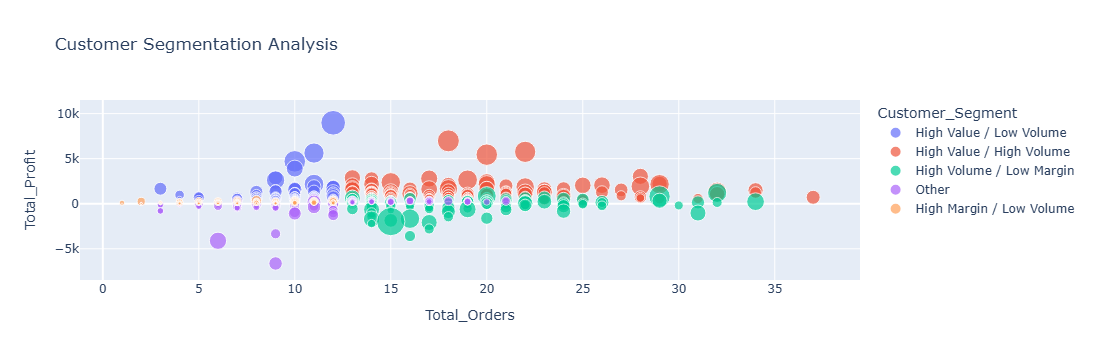

In [103]:
seg_df = _.DataFrame()
fig = px.scatter(seg_df,x="Total_Orders",y="Total_Profit",color="Customer_Segment",size="Total_Sales",hover_name="Customer Name",title="Customer Segmentation Analysis")
fig.show()

In [104]:
## Scatter Plot

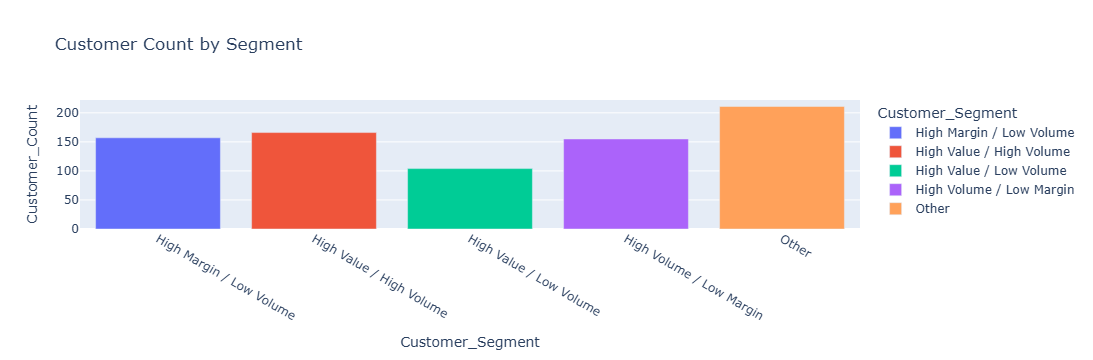

In [105]:
segment_counts = (
    seg_df.groupby("Customer_Segment")
          .size()
          .reset_index(name="Customer_Count")
)

fig = px.bar(
    segment_counts,
    x="Customer_Segment",
    y="Customer_Count",
    color="Customer_Segment",
    title="Customer Count by Segment"
)

fig.show()

In [106]:
# REGIONAL ANALYSIS

In [107]:
## Most profitable regions with highest-margin

In [108]:
%%sql
WITH regional_metrics AS (
    SELECT
        Region,
        ROUND(SUM(sales), 2) AS Total_Sales,
        ROUND(SUM(profit), 2) AS Total_Profit,
        ROUND(
            SUM(profit) / NULLIF(SUM(sales), 0) * 100,
            2
        ) AS Profit_Margin
    FROM retail_data
    GROUP BY Region
),

benchmarks AS (
    SELECT
        AVG(Total_Sales) AS Avg_Sales,
        AVG(Total_Profit) AS Avg_Profit,
        AVG(Profit_Margin) AS Avg_Margin
    FROM regional_metrics
)

SELECT
    r.*,
    CASE
        WHEN r.Total_Sales >= b.Avg_Sales
         AND r.Total_Profit >= b.Avg_Profit
         AND r.Profit_Margin >= b.Avg_Margin
            THEN 'High Value'

        WHEN r.Total_Sales < b.Avg_Sales
         AND r.Total_Profit < b.Avg_Profit
         AND r.Profit_Margin < b.Avg_Margin
            THEN 'Low Value'

        ELSE 'Mixed Performance'
    END AS Regional_Segment
FROM regional_metrics r
CROSS JOIN benchmarks b;

Running query in 'duckdb://'

Region,Total_Sales,Total_Profit,Profit_Margin,Regional_Segment
East,678781.24,91522.78,13.48,High Value
West,725457.82,108418.45,14.94,High Value
South,391721.91,46749.43,11.93,Low Value
Central,501239.89,39706.36,7.92,Low Value


In [109]:
## Regional Charts

In [110]:
regional_df = _.DataFrame()
2
 
3
print(regional_df.head())

    Region  Total_Sales  Total_Profit  Profit_Margin Regional_Segment
0     East    678781.24      91522.78          13.48       High Value
1  Central    501239.89      39706.36           7.92        Low Value
2    South    391721.91      46749.43          11.93        Low Value
3     West    725457.82     108418.45          14.94       High Value


In [111]:
## Scatter Plot

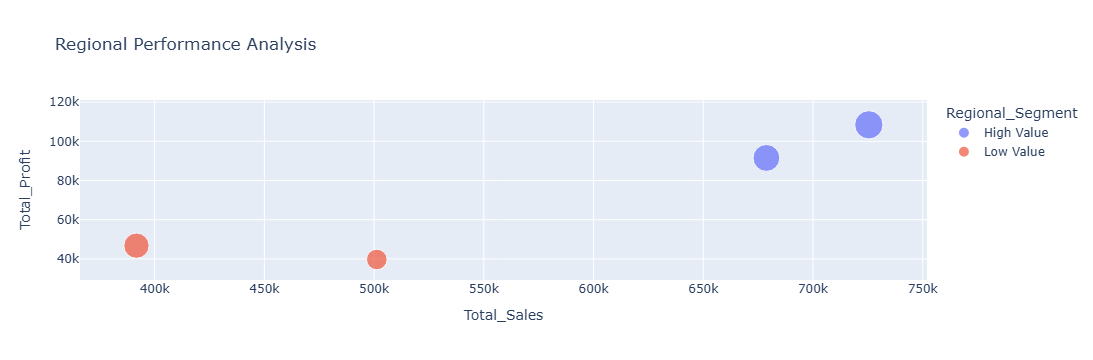

In [112]:
import plotly.express as px

fig = px.scatter(
    regional_df,
    x="Total_Sales",
    y="Total_Profit",
    color="Regional_Segment",
    size="Profit_Margin",
    hover_name="Region",
    title="Regional Performance Analysis"
)

fig.show()

In [113]:
## Sales vs Profit Benchmark Line Chart

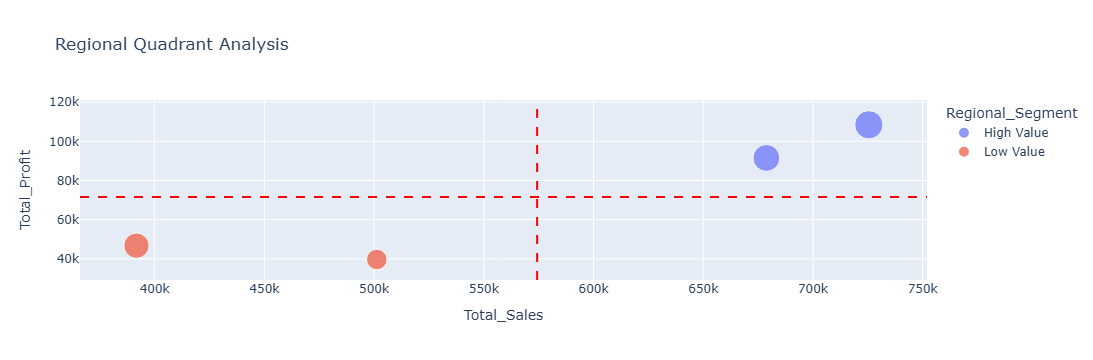

In [114]:
avg_sales = regional_df["Total_Sales"].mean()
avg_profit = regional_df["Total_Profit"].mean()

fig = px.scatter(
    regional_df,
    x="Total_Sales",
    y="Total_Profit",
    color="Regional_Segment",
    size="Profit_Margin",
    hover_name="Region",
    title="Regional Quadrant Analysis"
)

fig.add_vline(
    x=avg_sales,
    line_dash="dash",
    line_color="red"
)

fig.add_hline(
    y=avg_profit,
    line_dash="dash",
    line_color="red"
)

fig.show()

In [115]:
## Regional Scorecard Bar Chart

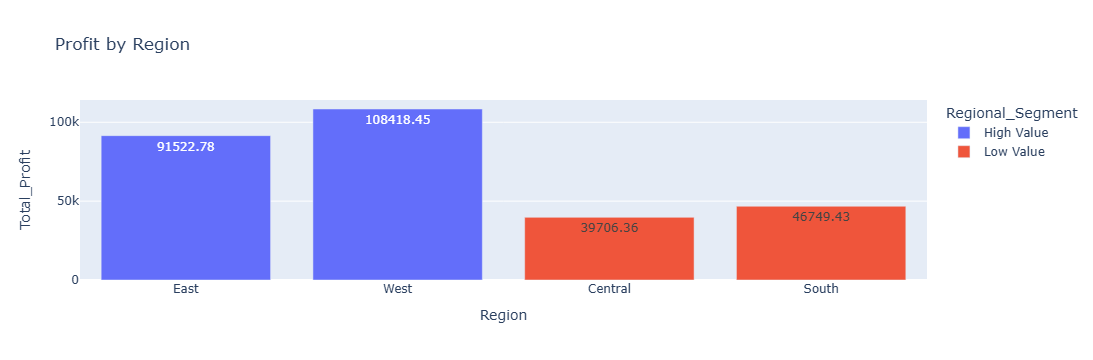

In [116]:
fig = px.bar(
    regional_df,
    x="Region",
    y="Total_Profit",
    color="Regional_Segment",
    text="Total_Profit",
    title="Profit by Region"
)

fig.show()

In [117]:
# PRODUCT ANALYSIS

In [118]:
## Most popular products ordered by the top customers

In [119]:
%%sql
WITH customer_product_counts AS (
    -- Count how many times each customer ordered each unique product
    SELECT 
        "Customer ID", 
        "Customer Name", 
        "Product Name",
        COUNT("Order ID") AS product_order_count,
        -- Total volume across ALL products for this customer (to rank the customers themselves)
        SUM(COUNT("Order ID")) OVER(PARTITION BY "Customer ID") AS total_customer_orders
    FROM retail_data 
    GROUP BY "Customer ID", "Customer Name", "Product Name"
),
ranked_products AS (
    -- Rank the products FOR EACH CUSTOMER based on popularity
    SELECT 
        "Customer ID",
        "Customer Name",
        "Product Name",
        product_order_count,
        total_customer_orders,
        DENSE_RANK() OVER(
            PARTITION BY "Customer ID" 
            ORDER BY product_order_count DESC
        ) AS product_preference_rank
    FROM customer_product_counts
)
-- Filter for only the #1 top product per customer, sorted by your highest-ordering customers
SELECT 
    "Customer ID",
    "Customer Name",
    "Product Name" AS favorite_product,
    product_order_count AS times_ordered_by_customer,
    total_customer_orders AS total_orders_placed
FROM ranked_products
WHERE product_preference_rank = 1
ORDER BY total_orders_placed DESC
Limit 10;

Running query in 'duckdb://'

Customer ID,Customer Name,favorite_product,times_ordered_by_customer,total_orders_placed
WB-21850,William Brown,Fellowes 8 Outlet Superior Workstation Surge Protector,2,37
MA-17560,Matt Abelman,"Acco Smartsocket Table Surge Protector, 6 Color-Coded Adapter Outlets",1,34
MA-17560,Matt Abelman,Xerox 1977,1,34
MA-17560,Matt Abelman,Logitech G35 7.1-Channel Surround Sound Headset,1,34
MA-17560,Matt Abelman,OIC Stacking Trays,1,34
MA-17560,Matt Abelman,"Commercial WindTunnel Clean Air Upright Vacuum, Replacement Belts, Filtration Bags",1,34
MA-17560,Matt Abelman,Nu-Dell Float Frame 11 x 14 1/2,1,34
MA-17560,Matt Abelman,Hon Non-Folding Utility Tables,1,34
JL-15835,John Lee,"Howard Miller 11-1/2"" Diameter Grantwood Wall Clock",2,34
MA-17560,Matt Abelman,Xerox 1884,1,34


In [120]:
## Most profitable products

In [121]:
%%sql
SELECT
    "Product Name",
    ROUND(SUM(sales), 2) AS Total_Sales,
    ROUND(SUM(profit), 2) AS Total_Profit,
    ROUND(
        SUM(profit) / NULLIF(SUM(sales), 0) * 100,
        2
    ) AS Profit_Margin
FROM retail_data
GROUP BY "Product Name" 
ORDER BY Total_Profit DESC;

Running query in 'duckdb://'

Product Name,Total_Sales,Total_Profit,Profit_Margin
Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,40.91
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04,28.24
Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,37.07
Canon PC1060 Personal Laser Copier,11619.83,4570.93,39.34
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.9,4094.98,22.29
Ativa V4110MDD Micro-Cut Shredder,7699.89,3772.95,49.0
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.89,3717.97,26.0
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.29,3696.28,39.46
Ibico EPK-21 Electric Binding System,15875.92,3345.28,21.07
Zebra ZM400 Thermal Label Printer,6965.7,3343.54,48.0


In [122]:
## Highest-margin products

In [123]:
%%sql
SELECT
    "Product Name",
    ROUND(SUM(sales), 2) AS Total_Sales,
    ROUND(SUM(profit), 2) AS Total_Profit,
    ROUND(
        SUM(profit) / NULLIF(SUM(sales), 0) * 100,
        2
    ) AS Profit_Margin
FROM retail_data
GROUP BY "Product Name" 
ORDER BY Profit_Margin DESC;

Running query in 'duckdb://'

Product Name,Total_Sales,Total_Profit,Profit_Margin
Xerox 1890,244.7,122.35,50.0
Avery 475,266.4,133.2,50.0
"Adams Telephone Message Book w/Frequently-Called Numbers Space, 400 Messages per Book",223.44,111.72,50.0
Tops Green Bar Computer Printout Paper,342.58,171.29,50.0
Canon imageCLASS MF7460 Monochrome Digital Laser Multifunction Copier,3991.98,1995.99,50.0
Southworth Structures Collection,72.8,36.4,50.0
Xerox 1987,92.48,45.32,49.0
Xerox 1983,29.9,14.65,49.0
Personal Creations Ink Jet Cards and Labels,321.44,157.51,49.0
"Strathmore #10 Envelopes, Ultimate White",632.52,309.93,49.0


In [124]:
## Highest volume of products order by region

In [125]:
%%sql
Select "Product Name", Region, COUNT(DISTINCT "Order ID") AS "Total_Orders"
From retail_data
GROUP BY ("Product Name",Region)
ORDER BY "Total_Orders" DESC; 

Running query in 'duckdb://'

Product Name,Region,Total_Orders
Staple envelope,East,17
Easy-staple paper,East,15
Staple envelope,Central,13
Staples,West,13
Easy-staple paper,Central,13
Staples,Central,13
Staples,East,11
Staple envelope,West,10
Staples,South,9
Easy-staple paper,West,9


In [126]:
## Most popular category sold for products

In [127]:
%%sql
Select "Product Name", Category, COUNT(DISTINCT "Order ID") AS "Total_Orders"
From retail_data
GROUP BY ("Product Name",Category)
ORDER BY "Total_Orders" DESC; 

Running query in 'duckdb://'

Product Name,Category,Total_Orders
Staple envelope,Office Supplies,48
Easy-staple paper,Office Supplies,46
Staples,Office Supplies,46
Avery Non-Stick Binders,Office Supplies,20
Staples in misc. colors,Office Supplies,19
Staple remover,Office Supplies,18
KI Adjustable-Height Table,Furniture,18
Storex Dura Pro Binders,Office Supplies,17
Staple-based wall hangings,Furniture,16
Logitech 910-002974 M325 Wireless Mouse for Web Scrolling,Technology,15


In [128]:
## Products with highest average returns

In [129]:
%%sql
Select Category,COUNT(Returned) AS Volume_Returned
FROM retail_data
WHERE Returned = 'Yes'
GROUP BY Category
ORDER BY Volume_Returned DESC ;

Running query in 'duckdb://'

Category,Volume_Returned
Office Supplies,473
Furniture,171
Technology,156


In [130]:
## Average discount broken out by category

In [131]:
%%sql
Select Category,ROUND(AVG(Discount),2) AS Average_Discount
From retail_data
WHERE Discount > 0
GROUP BY Category
ORDER BY Average_Discount DESC;

Running query in 'duckdb://'

Category,Average_Discount
Office Supplies,0.33
Furniture,0.29
Technology,0.24


In [132]:
## SHIPPING ANALYSIS

In [133]:
## Product delivery time from time of order, broken out by ship mode

In [134]:
%%sql
SELECT "Ship Mode",COUNT("Ship Mode") AS Ship_Mode_Volume,
       AVG(date_diff('day', "Order Date", "Ship Date")) AS Order_To_Delivery_Time
FROM retail_data
GROUP BY "Ship Mode"
Order BY Order_To_Delivery_Time Desc;

Running query in 'duckdb://'

Ship Mode,Ship_Mode_Volume,Order_To_Delivery_Time
Standard Class,5968,41.850871313672926
Second Class,1945,30.559383033419024
First Class,1538,23.53771131339402
Same Day,543,0.8802946593001841


In [135]:
%%sql
Select * 
From retail_data
Limit 1; 

Running query in 'duckdb://'

OGC_FID,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Retail Sales People,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit
2,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Cassandra Brandow,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,Not,261.96,2,0.0,41.9136
